# The Geysers 929: QuakeCastNet Training and Evaluation

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ.pop("SLURM_JOB_ID", None)
os.environ.pop("SLURM_NTASKS", None)
os.environ.pop("SLURM_JOB_NAME", None)
os.environ.pop("SLURM_NODELIST", None)
os.environ.setdefault("TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD", "1")
import re
import shutil
import random
import math
import warnings
from datetime import datetime, timedelta
warnings.filterwarnings("ignore")
import torch
torch.backends.cudnn.benchmark = True  

import glob, json as _json

In [2]:
import copy
from pathlib import Path
import warnings

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np
import pandas as pd
import ot

from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

In [3]:
from pytorch_forecasting import Baseline, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss, QuantileMaskLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.utils import WarmupSchedulerCallback
from pytorch_lightning.loggers import CSVLogger

from lightning.pytorch.callbacks import ModelCheckpoint

from models import TemporalFusionTransformerNew, CompositeQuantileLoss, RollingConfig, run_gated_recentered
from models.branchwise_transport_spatial import (
    BranchwiseTransportSpatialModel, BranchwiseTransportSpatialConfig,
)
from models.spatial_branch_eval import (
    load_catalog, events_to_cells, spatial_log_likelihood,
    kl_divergence, js_divergence,
)

import draw1, draw2, utils

## Load data


In [4]:
batch_size = 1024 
max_epochs = 200
model_save_epoch = 10
num_workers = 0
DO_TRAINING = False
precision = "32-true" # "32-true, 16-mixed"
NM_SEEDS = [0, 1, 2]  
NM_ALPHA = 0.0
n_enc = 800
n_dec = 320
downsample_rate = 4

max_prediction_length = n_dec // downsample_rate
max_encoder_length = n_enc // downsample_rate
print(f"max_encoder_length: {max_encoder_length}")
print(f"max_prediction_length: {max_prediction_length}")

year, month, day = 2012, 7, 1
zero_date = datetime(year, month, day, 0, 0)
print(f"zero_date: {zero_date}")
zero_text = zero_date.strftime("%Y-%m-%d")

log_name = "geysers929_i200o80t2012-07-01"
print(f"log_name: {log_name}")

normm = "min_max" 

max_encoder_length: 200
max_prediction_length: 80
zero_date: 2012-07-01 00:00:00
log_name: geysers929_i200o80t2012-07-01


In [5]:
dataset_path = os.path.join('preparation', 'dataset', 'Geysers929')

data_dict = np.load(
    os.path.join(dataset_path, 'seismic_inject_dataset929_ext.npy'),
    allow_pickle=True
).item()

seismic_rate = data_dict['seis_rate']
injection_rate = data_dict['inj_rate']
injection_rate_grad = np.gradient(injection_rate)
time_axis = data_dict['time_axis']

seismic_rate, injection_rate, injection_rate_grad, norm_param = utils.normalize_features(
    seismic_rate,
    injection_rate,
    injection_rate_grad,
    normm=normm,
)

interval_days_original = int(pd.Timedelta(time_axis[1] - time_axis[0]).total_seconds() / (24 * 3600))
interval_days = downsample_rate * interval_days_original
time_axis, seismic_rate, injection_rate, injection_rate_grad = utils.downsample_time_series(
    time_axis, seismic_rate, injection_rate, injection_rate_grad, 
    rule=f"{interval_days}D")

meta = {
    'time_axis': time_axis,
    'seismic_rate': seismic_rate,
    'injection_rate': injection_rate,
    'injection_rate_grad': injection_rate_grad,
    'norm_param': norm_param,
}

In [6]:
def get_geysers_segments(
    border1s, 
    border2s, 
    time_axis,
    seismic_rate, 
    injection_rate, 
    injection_rate_grad,  
    w_len, 
    w_step=1,
):
    
    border1, border2 = border1s[0], border2s[0] 
    
    train_data_list = []
    icount = 0
    for j0 in range(border1, border2+1, w_step):
        j1 = j0 + w_len
    
        if j1 > n_len:
            j0 = n_len - w_len
            j1 = n_len

        date = np.array([x for x in time_axis[j0:j1]])
        data_dict = {
            'seismic_rate': seismic_rate[j0:j1],
            'injection_rate': injection_rate[j0:j1],
            'injection_rate_grad': injection_rate_grad[j0:j1],
            'date': date,
            'time_idx': np.arange(j1 - j0, dtype=np.int64),  
            'group_id': icount,
        }
        
        icount += 1
        train_data_list.append(data_dict)
        if j1 == n_len:
            break

    border1, border2 = border1s[1], border2s[1] 
    valid_data_list = []
    w_len = max_encoder_length + max_prediction_length
    for j0 in range(border1, border2+1, w_step):
        j1 = j0 + w_len
    
        if j1 > n_len:
            j0 = n_len - w_len
            j1 = n_len

        date = np.array([x for x in time_axis[j0:j1]])
        data_dict = {
            'seismic_rate': seismic_rate[j0:j1],
            'injection_rate': injection_rate[j0:j1],
            'injection_rate_grad': injection_rate_grad[j0:j1],
            'date': date,
            'time_idx': np.arange(j1 - j0, dtype=np.int64),  
            'group_id': icount,
        }
                
        icount += 1
        valid_data_list.append(data_dict)
        if j1 == n_len:
            break
    return train_data_list, valid_data_list

In [7]:
start_date = time_axis[0]
end_date = time_axis[-1]
n_len = len(time_axis)
zero_index = np.where( (time_axis >= zero_date) & (time_axis < zero_date + timedelta(days=interval_days)) )[0][0]
start_index = 0
end_index = n_len - 1

w_len = max_encoder_length + max_prediction_length
border1s = [start_index, zero_index - w_len]
border2s = [zero_index - w_len, end_index]          

# building training data
train_data_list, valid_data_list = get_geysers_segments(
    border1s, 
    border2s, 
    time_axis,
    seismic_rate, 
    injection_rate, 
    injection_rate_grad, 
    w_len, 
    w_step=1,
)

valid_data_list, apply_data_list = valid_data_list[:max_prediction_length], valid_data_list[max_prediction_length:]

# Recent-level anchor (L1): per-window stats of the encoder-tail target level, fed to the TFT
# via static_reals. A long-run (800-day) mean goes stale as the level drifts within a window,
# so only recent stats are used.
for seg in train_data_list + valid_data_list + apply_data_list:
    _enc = seg['seismic_rate'][:max_encoder_length]
    seg['enc_seis_tail5'] = float(_enc[-5:].mean())    # mean of last 5 bins (~20 days): latest level
    seg['enc_seis_tail20'] = float(_enc[-20:].mean())  # mean of last 20 bins (~80 days): recent level

print(f"Train Samples: {len(train_data_list)}")
print(f"Valid Samples: {len(valid_data_list)}")
print(f"Apply Samples: {len(apply_data_list)}")

Train Samples: 39
Valid Samples: 80
Apply Samples: 208


1st Y-axis range: (np.float64(-0.04819904848680468), np.float64(1.0121800182228984))
2nd Y-axis range: (np.float64(-0.04929814550949074), np.float64(1.0448102436988462))


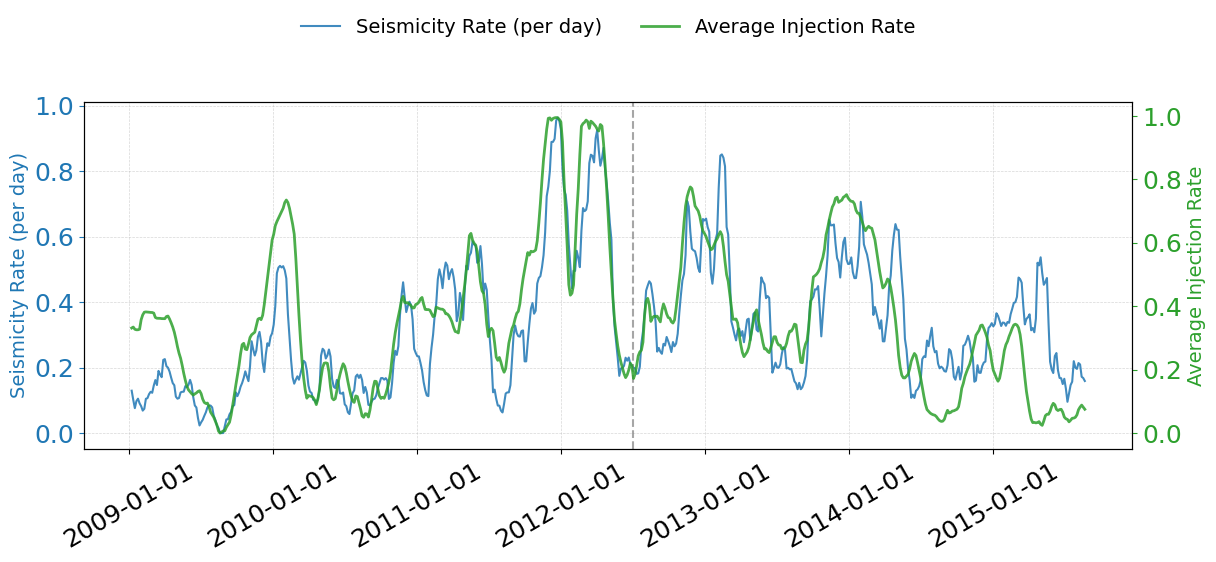

In [8]:
draw1.draw_sequence_diff(
    [
        [meta['time_axis'], meta['seismic_rate']],
        [meta['time_axis'], meta['injection_rate']],
    ],
    mark_datetime = [zero_date],
    labels = [f'Seismicity Rate (per day)', 'Average Injection Rate', 'Accumulated Seismic Moment'],
    figsize=(12,5),
)

In [9]:
target = "seismic_rate"
time_varying_known_reals = ["injection_rate", "injection_rate_grad"]

train_data_set = utils.lists_to_df(train_data_list, target, time_varying_known_reals)
valid_data_set = utils.lists_to_df(valid_data_list, target, time_varying_known_reals)
apply_data_set = utils.lists_to_df(apply_data_list, target, time_varying_known_reals)

### Create dataset and dataloaders


In [10]:
training = TimeSeriesDataSet(
    train_data_set,
    time_idx="time_idx",
    target=target,
    group_ids=["group_id"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=[],
    static_reals=["enc_seis_tail5", "enc_seis_tail20"],
    scalers={
        "enc_seis_tail5": None,
        "enc_seis_tail20": None,
    },
    time_varying_known_categoricals=[],
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=[target],
    categorical_encoders={      
        "group_id": NaNLabelEncoder(add_nan=True)
    },
    target_normalizer=None,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(training, valid_data_set, predict=True, stop_randomization=True)
application = TimeSeriesDataSet.from_dataset(training, apply_data_set, predict=True, stop_randomization=True)

# create dataloaders for model
loader_kwargs = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "pin_memory": True,
    "persistent_workers": num_workers > 0,
    "drop_last": False,
}
train_dataloader = training.to_dataloader(
    train=True,
    **loader_kwargs,
)
valid_dataloader = validation.to_dataloader(
    train=False,
    **loader_kwargs,
)
apply_dataloader = application.to_dataloader(
    train=False,
    **loader_kwargs,
)

## Train the Temporal Fusion Transformer

In [11]:
if DO_TRAINING:
    for _seed in NM_SEEDS:
        pl.seed_everything(_seed, workers=True)
        _logger = CSVLogger("./logs/", name=log_name, version=f"seed_{_seed}")
        _ckpt_cb = ModelCheckpoint(dirpath=os.path.join(_logger.log_dir, "ckpts"),
                                   save_top_k=1, filename="{epoch}-{step}")
        _trainer = pl.Trainer(
            max_epochs=max_epochs, accelerator="gpu", devices=1, precision=precision,
            gradient_clip_val=0.1, callbacks=[LearningRateMonitor(), _ckpt_cb],
            logger=_logger, num_sanity_val_steps=0, enable_model_summary=False)
        
        _tft = TemporalFusionTransformerNew.from_dataset(
            training, learning_rate=0.03, hidden_size=64, attention_head_size=4,
            dropout=0.1, hidden_continuous_size=32,
            loss=CompositeQuantileLoss(alpha=NM_ALPHA),
            log_interval=10, optimizer="ranger", reduce_on_plateau_patience=4)

        _trainer.fit(_tft, train_dataloaders=train_dataloader,
                     val_dataloaders=valid_dataloader)
        print(f"seed {_seed} done")

## Evaluate performance

In [12]:
log_path = os.path.join("./logs/", log_name)
version_list = [x for x in os.listdir(log_path) if x.startswith('version')]
version = sorted(version_list, key=lambda x:int(x.split('_')[-1]))[-1]

results_path = os.path.join(log_path, version)
os.makedirs(results_path, exist_ok=True)
print(f"results_path: {results_path}")

norm_stats = {
    key: np.asarray(list(value.values()))
    for key, value in meta["norm_param"].items()
}
time_axis_all = meta['time_axis'].copy()

results_path: ./logs/geysers929_i200o80t2012-07-01/version_0


In [13]:
_cache17 = os.path.join(results_path, f"tft_new_results.npy")

if os.path.exists(_cache17):
    results = np.load(_cache17, allow_pickle=True)
    print(f"[cache] results={len(results)} windows <- {_cache17}")
    
else:
    NM_FT_LR, NM_FT_STEPS = 3e-3, 100
    
    _nm_ckpts = []
    for _seed in NM_SEEDS:
        _c = sorted(glob.glob(f"./logs/{log_name}/seed_{_seed}/ckpts/*.ckpt"),
                    key=lambda x: int(x.split("=")[1].split("-")[0]))
        if _c:
            _nm_ckpts.append(_c[-1])
    print(f"[nm4] ckpts (M={len(_nm_ckpts)}): {_nm_ckpts}")
    
    if len(_nm_ckpts) == len(NM_SEEDS):
        results, _, _info = run_gated_recentered(
            RollingConfig(ft_lr=NM_FT_LR, ft_steps=NM_FT_STEPS,
                          alpha=NM_ALPHA, batch_size=1024),
            ckpt_paths=_nm_ckpts, training_template=training,
            train_data_list=train_data_list, apply_data_list=apply_data_list,
            target=target, known_reals=time_varying_known_reals,
            time_axis=meta["time_axis"],
            norm_stats={k: np.asarray(list(v.values())) for k, v in meta["norm_param"].items()})

        np.save(_cache17, np.array(results, dtype=object))
        print(f"[saved] {_cache17} ({len(results)} windows)")
        
    else:
        print("[nm4] ckpts incomplete")

[cache] results=208 windows <- ./logs/geysers929_i200o80t2012-07-01/version_0/tft_new_results.npy


In [14]:
# Load cached results
cache_files = {
    "results_new": os.path.join(
        results_path,
        "tft_new_results.npy",
    ),
}
for var_name, path in cache_files.items():
    if os.path.exists(path):
        print(path)
        globals()[var_name] = np.load(path, allow_pickle=True)

results_sets = {
    "current": results_new, 
}

./logs/geysers929_i200o80t2012-07-01/version_0/tft_new_results.npy


## Spatial Distribution of Seismicity

In [15]:
results = results_sets["current"]
sp_catalog = load_catalog(os.path.join(
    'preparation', 'raw_data', 'Geysers929', 'geysers929_catalog_processed.csv'))
sw_grid = data_dict['sw_grid']
n_grid = int(sw_grid['n_grid'])
n_cells = n_grid * n_grid

sp_model = BranchwiseTransportSpatialModel(
    sw_grid, artifact=None,
    config=BranchwiseTransportSpatialConfig(
        tau_days=320.0, active_tau_days=320.0, variant='unsharpened',
        kde_bandwidth_floor_km=0.05, kde_bandwidth_scale_km=0.05,
        gamma=1.0, beta=0.0,
    ),
)

H = len(results[0]['prediction'])
n_enc_sp = len(results[0]['date']) - H
dt_bin = pd.Timedelta(results[0]['date'][1] - results[0]['date'][0])
bin_days = dt_bin.total_seconds() / 86400.0


sp_windows = []
for k, r in enumerate(results):
    pred = np.asarray(r['prediction'], dtype=np.float64)
    if pred.ndim == 2:   
        pred = pred.mean(axis=1)
    t_issue = pd.Timestamp(r['date'][n_enc_sp - 1])
    sp_windows.append({
        'k': k,
        't_issue': t_issue,
        'fw_end': t_issue + H * dt_bin,
        'pred': pred,           # event rate (events/day), original units
        'N_pred': float(pred.sum() * bin_days),
    })

print(f"{len(sp_windows)} windows | horizon = {H} bins × {bin_days:.0f} days = {H * bin_days:.0f} days "
      f"| grid {n_grid}×{n_grid} = {n_cells} cells")
print(f"t_issue range: {sp_windows[0]['t_issue'].date()} → {sp_windows[-1]['t_issue'].date()}")
print(f"catalog events N = {len(sp_catalog['times'])} | N_pred range: "
      f"{min(w['N_pred'] for w in sp_windows):.1f} – {max(w['N_pred'] for w in sp_windows):.1f}")

208 windows | horizon = 80 bins × 4 days = 320 days | grid 32×32 = 1024 cells
t_issue range: 2012-06-29 → 2014-10-05
catalog events N = 1252 | N_pred range: 106.5 – 236.9


In [16]:
cat_lats, cat_lons = sp_catalog['lats'], sp_catalog['lons']
cat_mags, cat_times = sp_catalog['mags'], sp_catalog['times']
lat_edges = np.asarray(sw_grid['lat_edges'])
lon_edges = np.asarray(sw_grid['lon_edges'])
log_unif = np.log(1.0 / n_cells)

_lat_c = 0.5 * (lat_edges[:-1] + lat_edges[1:])
_lon_c = 0.5 * (lon_edges[:-1] + lon_edges[1:])
_LAT, _LON = np.meshgrid(_lat_c, _lon_c, indexing='ij')     # lat-major, consistent with sw flattening
lat0 = float(np.median(cat_lats))
lon0 = float(np.median(cat_lons))
grid_km = np.stack([(_LON.ravel() - lon0) * np.cos(np.deg2rad(lat0)) * 111.32,
                    (_LAT.ravel() - lat0) * 111.32], axis=1)
M_km = cdist(grid_km, grid_km)

sp_eval = []
for w in sp_windows:
    sw_fc = sp_model.predict(cat_lats, cat_lons, cat_mags, cat_times, w['t_issue'])
    in_fw = ((cat_times > w['t_issue'].to_datetime64())
             & (cat_times <= w['fw_end'].to_datetime64()))
    cells = events_to_cells(cat_lats[in_fw], cat_lons[in_fw], lat_edges, lon_edges, n_grid)
    cells = cells[cells >= 0]                   
    ll, K = spatial_log_likelihood(sw_fc, cells)
    if K > 0:
        obs_hist = np.bincount(cells, minlength=n_cells).astype(np.float64) / K
        gain = (ll - K * log_unif) / K            # nats/event, >0 beats uniform
        kl = kl_divergence(sw_fc, obs_hist)
        js = js_divergence(sw_fc, obs_hist)
        p_fc = np.ascontiguousarray(sw_fc, dtype=np.float64)
        emd = float(ot.emd2(p_fc / p_fc.sum(), obs_hist / obs_hist.sum(), M_km))
        rho = float(spearmanr(p_fc, obs_hist)[0])
        _order = np.argsort(p_fc)[::-1]
        hit10 = float(obs_hist[_order[:max(1, round(0.10 * n_cells))]].sum())
        hit20 = float(obs_hist[_order[:max(1, round(0.20 * n_cells))]].sum())
    else:
        obs_hist = np.full(n_cells, 1.0 / n_cells)
        gain, kl, js = np.nan, np.nan, np.nan
        emd, rho, hit10, hit20 = np.nan, np.nan, np.nan, np.nan
    sp_eval.append({**w, 'sw_fc': sw_fc, 'obs_hist': obs_hist,
                    'K': K, 'LL': ll, 'gain': gain, 'KL': kl, 'JS': js,
                    'EMD_km': emd, 'hit10': hit10, 'hit20': hit20, 'spearman': rho})
    
sp_df = pd.DataFrame([{k_: v for k_, v in e.items() if k_ not in ('sw_fc', 'obs_hist', 'pred')}
                      for e in sp_eval])

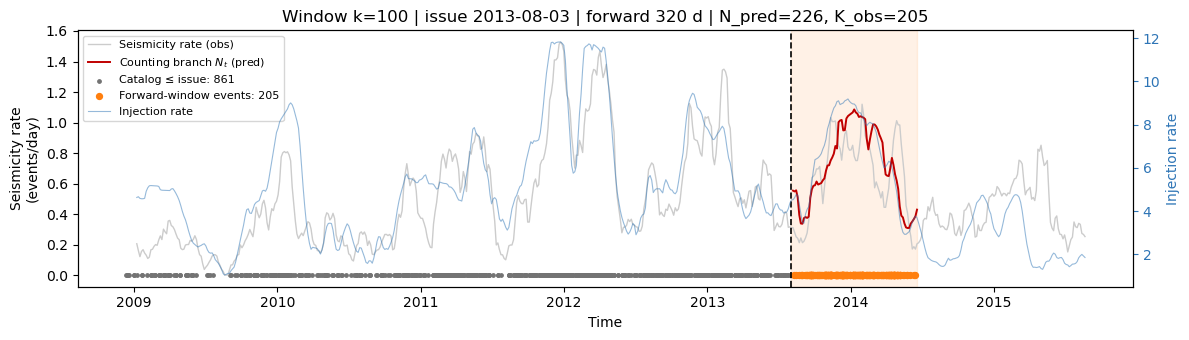

In [17]:
k = 100
e = sp_eval[k]
hist_sr = meta['seismic_rate'] * norm_stats['seismic_rate'][1] + norm_stats['seismic_rate'][0]
hist_inj = meta['injection_rate'] * norm_stats['injection_rate'][1] + norm_stats['injection_rate'][0]
dec_dates = pd.to_datetime(results[k]['date'][n_enc_sp:])
t_issue, fw_end = e['t_issue'], e['fw_end']

ct = sp_catalog['times']
train_ev = ct <= t_issue.to_datetime64()
fw_ev = (ct > t_issue.to_datetime64()) & (ct <= fw_end.to_datetime64())

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(meta['time_axis'], hist_sr, color='0.8', lw=1, label='Seismicity rate (obs)')
ax.plot(dec_dates, e['pred'], color='#c00000', lw=1.4, label='Counting branch $N_t$ (pred)')
y0 = float(hist_sr.min())
ax.scatter(ct[train_ev], np.full(int(train_ev.sum()), y0), s=6, c='0.45',
           label=f'Catalog ≤ issue: {int(train_ev.sum())}')
ax.scatter(ct[fw_ev], np.full(int(fw_ev.sum()), y0), s=18, c='#ff7f0e',
           label=f'Forward-window events: {int(fw_ev.sum())}')
ax.axvline(t_issue, color='k', lw=1.2, linestyle='--')
ax.axvspan(t_issue, fw_end, color='#ff7f0e', alpha=0.10)
ax.set_ylabel('Seismicity rate\n(events/day)')
ax.set_xlabel('Time')

ax2 = ax.twinx()
ax2.plot(meta['time_axis'], hist_inj, color='#2e75b6', lw=0.8, alpha=0.5, label='Injection rate')
ax2.set_ylabel('Injection rate', color='#2e75b6')
ax2.tick_params(axis='y', colors='#2e75b6')

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)
ax.set_title(f"Window k={k} | issue {t_issue.date()} | forward {int(H * bin_days)} d | "
             f"N_pred={e['N_pred']:.0f}, K_obs={e['K']}")
plt.tight_layout()
plt.show()

vmax: 1.7
normalized sum=1.000000 | common vmax(99%)=1.700000 | 50% HDR threshold=0.003463 | 80% HDR threshold=0.001428


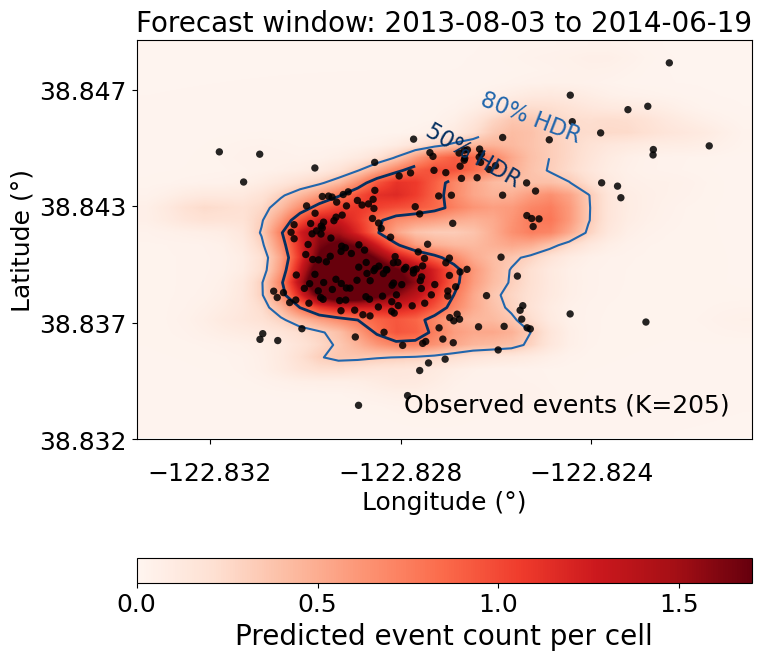

In [18]:
fontsize = 18

mpl.rcdefaults()
mpl.rcParams.update({
    "font.size": fontsize,
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "legend.fontsize": fontsize,
})

e = sp_eval[k]
lon_edges = np.asarray(sw_grid["lon_edges"])
lat_edges = np.asarray(sw_grid["lat_edges"])
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
prob = np.asarray(e["sw_fc"], dtype=np.float64).reshape(n_grid, n_grid)
prob = np.clip(prob, 0.0, None)
prob /= prob.sum()
lam = e["N_pred"] * prob

vmax = np.percentile(lam[lam > 0], 99)
vmax = 1.7
print(f"vmax: {vmax}")

fw_ev = (
    (cat_times > e["t_issue"].to_datetime64())
    & (cat_times <= e["fw_end"].to_datetime64())
)


fig, ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
im = ax.imshow(
    lam,
    extent=(lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]),
    origin="lower",
    cmap="Reds",
    vmin=0.0,
    vmax=vmax,
    interpolation="bilinear",
    aspect="auto",
    zorder=2,
)

# 50%/80% highest-density-region (HDR) boundaries.
_flat = prob.ravel()
_order = np.argsort(_flat)[::-1]
_cumulative = np.cumsum(_flat[_order])
def _hdr_threshold(mass):
    return float(_flat[_order[min(np.searchsorted(_cumulative, mass), len(_order) - 1)]])
_t50, _t80 = _hdr_threshold(0.50), _hdr_threshold(0.80)
_levels = sorted(set([_t80, _t50]))

if len(_levels) == 2:
    _cs = ax.contour(
        lon_centers, lat_centers, prob,
        levels=_levels,
        colors=["#2166ac", "#053061"],
        linewidths=[1.5, 2.0],
        zorder=4,
    )
    ax.clabel(_cs, fmt={_t80: "80% HDR", _t50: "50% HDR"}, fontsize=16)

ax.scatter(
    cat_lons[fw_ev], cat_lats[fw_ev],
    s=28, c="k", marker="o", alpha=0.85,
    edgecolors="none", linewidths=0.4, zorder=5,
    label=f"Observed events (K={int(fw_ev.sum())})",
)
ax.set_xlim(lon_edges[0], lon_edges[-1])
ax.set_ylim(lat_edges[0], lat_edges[-1])
ax.ticklabel_format(axis="x", style="plain", useOffset=False)
ax.set_title(
    f'Forecast window: {e["t_issue"].date()} to {e["fw_end"].date()}',
    fontsize=fontsize + 2,
)

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.legend(loc="lower right", frameon=False)
cbar = fig.colorbar(
    im, ax=ax, orientation="horizontal", location="bottom",
    fraction=0.08, pad=0.10, aspect=25,
)
# cbar.set_label("Forecast spatial probability", fontsize=fontsize + 2)
cbar.set_label(
    "Predicted event count per cell",
    fontsize=fontsize + 2,
)
cbar.ax.tick_params(labelsize=fontsize)


cbar_ticks = cbar.get_ticks()
cbar_ticks = cbar_ticks[(cbar_ticks >= im.norm.vmin) & (cbar_ticks <= im.norm.vmax)]
cbar.set_ticks(cbar_ticks[::2])
ax.tick_params(axis="x", pad=12)

xticks = ax.get_xticks(); xlim = ax.get_xlim()
ax.set_xticks(xticks[(xticks >= xlim[0]) & (xticks <= xlim[1])])
yticks = ax.get_yticks(); ylim = ax.get_ylim()
yticks = yticks[(yticks >= ylim[0]) & (yticks <= ylim[1])]

ax.set_xticks(ax.get_xticks()[::2])
ax.set_yticks(ax.get_yticks()[::2])
ax.yaxis.set_major_formatter(
    FormatStrFormatter("%.3f")
)


print(f"normalized sum={prob.sum():.6f} | common vmax(99%)={vmax:.6f} | "
      f"50% HDR threshold={_t50:.6f} | 80% HDR threshold={_t80:.6f}")
plt.show()


## Single Sample Visualization 

In [19]:
results = results_sets["current"]
k = 0
result_dict = results[k]

this_time_axis = result_dict['date']
this_injection_rate = result_dict['injection_rate']
this_seismic_rate = result_dict['seismic_rate']
seismic_rate_target = result_dict['target']
seismic_rate_prediction = result_dict['prediction']
target_index = result_dict['target_index']
this_group_id = result_dict['group_id']

all_index = np.arange(len(this_time_axis))
input_axis = np.array([j for j in all_index if j not in target_index])
input_axis = input_axis[-max_prediction_length*2:]

In [20]:
merges = utils.merge_and_evaluate_forecasts(results, time_axis_all)

seismic_rate_all_raw = meta['seismic_rate'] * norm_stats['seismic_rate'][1] + norm_stats['seismic_rate'][0]
injection_rate_all_raw = meta['injection_rate'] * norm_stats['injection_rate'][1] + norm_stats['injection_rate'][0]
injection_rate_grad_all_raw = meta['injection_rate_grad'] * norm_stats['injection_rate_grad'][1] + norm_stats['injection_rate_grad'][0]
seismic_rate_pred = merges['seismic_rate_pred']
seismic_rate_tgt = merges['seismic_rate_tgt']
global_index = merges['global_index']
global_index_inp = merges['global_index_inp']
time_axis_tgt = merges['time_axis_tgt']
time_axis_inp = merges['time_axis_inp']

1st Y-axis range: (np.float64(0.0), np.float64(1.6))
2nd Y-axis range: (np.float64(0.0), np.float64(13.0))


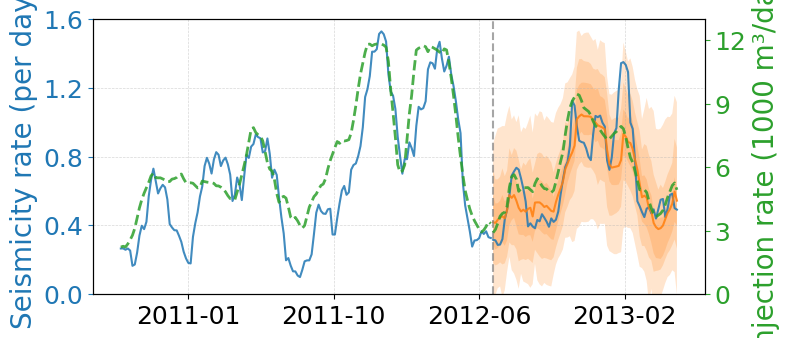

In [21]:
ylims=[
    (0.0, 1.6),
    (0.0, 13)
]
_pred_arr = np.asarray(seismic_rate_prediction, dtype=float)
_pred_mean = _pred_arr.mean(axis=-1) if _pred_arr.ndim > 1 else _pred_arr
_uncertainty = ([[[this_time_axis[target_index]], [_pred_arr.T]]] if _pred_arr.ndim > 1 else None)

draw1.draw_sequence_diff(
    [
        [
            [this_time_axis[input_axis], this_time_axis[target_index], this_time_axis[target_index]],
            [this_seismic_rate[input_axis], seismic_rate_target, _pred_mean],
        ],  
        [
            [this_time_axis[input_axis], this_time_axis[target_index]], 
            [this_injection_rate[input_axis], this_injection_rate[target_index]],
        ],
    ],
    mark_datetime = [this_time_axis[target_index[0]]],
    uncertainty=_uncertainty,
    labels = ['Seismicity rate (per day)', 'Injection rate (1000 m³/day)', 'Magnitude'],
    ylims=ylims,
    figsize=(8,4),
    nax = 5,
    nay = [4,5,4],
    time_format='ym',
    legend=False,
    fontsize=20,
    types=['line', 'line', 'scatter'],
    linestyles=[['-','-','-'],['--','--']],
    ucolor=[["#ff7f0e"]],
    lcolor = [["#1f77b4"]*2+['#ff7f0e'], ["#2ca02c", "#2ca02c", "#2ca02c"], ["#9467bd", "#e15759"]],
)

1st Y-axis range: (np.float64(-0.49040882460600316), np.float64(1.6402441122686613))
2nd Y-axis range: (np.float64(0.5049463649067965), np.float64(12.366281275540777))
3rd Y-axis range: (np.float64(-0.36701976756925814), np.float64(0.3876355856713194))


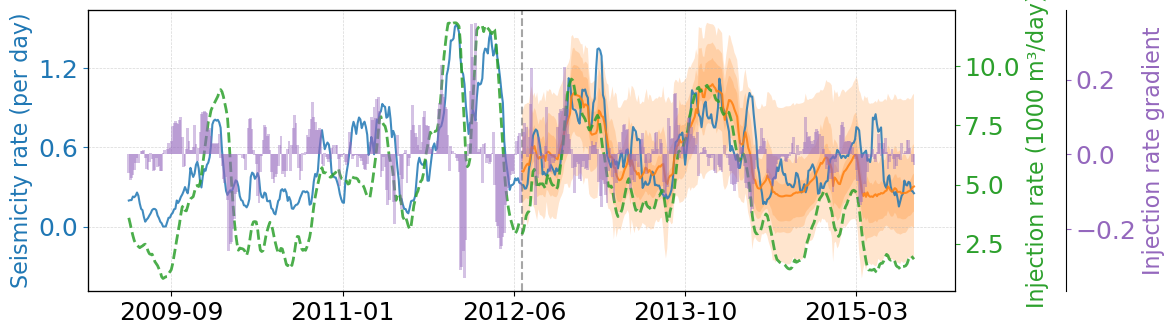

In [22]:
draw1.draw_sequence_diff(
    [
        [
            [time_axis_inp, time_axis_tgt, time_axis_tgt],
            [seismic_rate_all_raw[global_index_inp], seismic_rate_tgt, seismic_rate_pred.mean(axis=-1)],
        ],  
        [
            [time_axis_inp, time_axis_tgt], 
            [injection_rate_all_raw[global_index_inp], injection_rate_all_raw[global_index]],
        ],
        [
            [time_axis_inp, time_axis_tgt], 
            [injection_rate_grad_all_raw[global_index_inp], injection_rate_grad_all_raw[global_index]],
        ],
    ],
    mark_datetime = [time_axis_tgt[0]],
    uncertainty=[
        [[time_axis_tgt],
        [seismic_rate_pred.T],]
    ],
    labels = ['Seismicity rate (per day)', 'Injection rate (1000 m³/day)', 'Injection rate gradient'],
    figsize=(12,4),
    nax = 6,
    nay = [4,5,4],
    time_format='ym',
    legend=False,
    fontsize=16,
    types=['line', 'line', 'bar'],
    linestyles=[['-','-','-'],['--','--']],
    ucolor=[["#ff7f0e"]],
    lcolor = [["#1f77b4"]*2+['#ff7f0e'], ["#2ca02c", "#2ca02c", "#2ca02c"], ["#9467bd", "#e15759"]] 
)